# Sentiment Analysis of Cyberpunk 2077 — Steam Reviews
### A Natural Language Processing Project

**Project Goal:** Apply 15 NLP methods from our lecture to ~92,000 **recent** Steam reviews of Cyberpunk 2077 (the data spans **July 2024 – June 2026**, i.e. *after* the game was fixed) and answer:  
*"Now that Cyberpunk 2077 is one of Steam's highly-rated titles, how do players feel about it today, what do they still praise and complain about, and can we build a system to search and question 92,000 opinions?"*

> **Note on the data:** every review here is from the post-recovery period, so this project is a **snapshot of the current game** (what players think now, by platform and by topic) — it is *not* a launch-to-now redemption story, because the 2020 launch is outside the dataset.

**Methods used (all from the NLP lecture):**

| # | Method | Library |
|---|--------|---------|
| 1 | Tokenization | spaCy |
| 2 | Stop-word removal | spaCy |
| 3 | Lemmatization | spaCy |
| 4 | Stemming (Porter) | NLTK Snowball (comparison) |
| 5 | POS Tagging | spaCy |
| 6 | Named Entity Recognition | spaCy |
| 7 | Pattern Matching | spaCy Matcher |
| 8 | N-gram Analysis | sklearn CountVectorizer |
| 9 | tf-idf Vectorization | sklearn TfidfVectorizer |
| 10 | Levenshtein Distance | python-Levenshtein |
| 11 | N-gram Similarity (Dice/Jaccard) | manual implementation |
| 12 | Sentiment Classification | sklearn LogisticRegression |
| 13 | Word Embeddings (Word2Vec) | gensim |
| 14 | Search Engine (tf-idf cosine) | sklearn |
| 15 | RAG (Retrieval-Augmented Generation) | Search Engine + LLM API |

---
## Phase 0 — Data Loading
Load the dataset of ~92,000 English-language Steam reviews scraped via the Steam API.  
Each review has: the review text, a thumbs-up/down vote, helpfulness votes, playtime, and a timestamp.

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Load the scraped Steam reviews
df = pd.read_csv('data/steam_reviews_dataset.csv')

# Quick overview
print(f"Dataset shape: {df.shape}")
print(f"\nPositive reviews: {df['voted_up'].sum():,}")
print(f"Negative reviews: {(~df['voted_up']).sum():,}")
print(f"Null reviews:     {df['review_text'].isna().sum()}")

# Drop rows with empty review text
df = df.dropna(subset=['review_text'])
print(f"\nAfter dropping nulls: {len(df):,} reviews")

# Add a readable date column from the Unix timestamp
df['date'] = pd.to_datetime(df['timestamp_created'], unit='s')
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

df.head()

Dataset shape: (92190, 5)

Positive reviews: 87,406
Negative reviews: 4,784
Null reviews:     491

After dropping nulls: 91,699 reviews
Date range: 2024-07-19 to 2026-06-25


,review_text,voted_up,votes_up,playtime_forever,timestamp_created,date
0,Amazing game if u want easy/hard game with emo...,True,0,1229,1782386757,2026-06-25 11:25:57
1,The Witcher 3 is my favourite game of all time...,True,0,5655,1782385701,2026-06-25 11:08:21
2,yes id recommend now stop asking,True,0,1985,1782385340,2026-06-25 11:02:20
3,THE MOST PEAK REDEMPTION ARC OF GAMING INDUSTR...,True,0,13815,1782384391,2026-06-25 10:46:31
4,"I haven't finished the game yet, but I absolut...",True,0,2874,1782384275,2026-06-25 10:44:35


---
### Real-Time Data: Fetching Live Reviews from the Steam API

Instead of only working with a static CSV, we also fetch the **latest reviews in real-time** 
from Steam's public API. This demonstrates:
- **Web Crawling** (from the lecture — Chapter 6: how to programmatically retrieve web data)
- **API-based data collection** (a modern alternative to HTML crawling)
- The project always has the freshest data, not just a snapshot

Steam API endpoint: `https://store.steampowered.com/appreviews/1091500?json=1`

---
## Phase 1 — Text Preprocessing with spaCy

All preprocessing uses **spaCy**, the library taught in our lecture.  
The spaCy pipeline runs tokenization, lemmatization, POS tagging, and NER in a single pass — 
this is more efficient than calling separate NLTK functions.

### Method 1: Tokenization
**Definition:** Tokenization is the segmentation of text into units at the word level.  
We use `nlp()` which runs the full spaCy pipeline and gives us Token objects.

### Method 2: Stop-word removal  
**Definition:** Stop words are frequent words (the, is, and) that carry no content meaning.  
spaCy marks them with `token.is_stop`.

### Method 3: Lemmatization  
**Definition:** Lemmatization finds the dictionary base form of a word (e.g., "running" → "run").  
spaCy provides this via `token.lemma_`.

In [2]:
import requests
import time
from datetime import datetime

print("=" * 70)
print("REAL-TIME DATA — Fetching latest Cyberpunk 2077 reviews from Steam API")
print("=" * 70)

CYBERPUNK_APP_ID = "1091500"
STEAM_API_URL = f"https://store.steampowered.com/appreviews/{CYBERPUNK_APP_ID}"

def fetch_steam_reviews(num_reviews=500, language='english'):
    """
    Fetch recent reviews from the Steam API in real-time.
    
    This is web crawling (Chapter 6 of the lecture) — but using an API 
    instead of parsing HTML. The Steam API returns structured JSON, 
    so we don't need BeautifulSoup here.
    
    The API uses a cursor for pagination (like a crawler's BFS queue):
    → fetch page 1 → get cursor → fetch page 2 → get cursor → ...
    """
    all_reviews = []
    cursor = '*'   # Steam uses '*' as the initial cursor
    
    params = {
        'json': 1,
        'filter': 'recent',          # Get newest reviews first
        'language': language,
        'num_per_page': 100,          # Max 100 per request
        'purchase_type': 'all',
        'review_type': 'all',        # Both positive and negative
    }
    
    print(f"\nFetching up to {num_reviews} reviews from Steam API...")
    
    while len(all_reviews) < num_reviews:
        params['cursor'] = cursor
        
        try:
            response = requests.get(STEAM_API_URL, params=params, timeout=15)
            data = response.json()
            
            if data.get('success') != 1:
                print(f"  API error — stopping at {len(all_reviews)} reviews")
                break
            
            reviews = data.get('reviews', [])
            if not reviews:
                print(f"  No more reviews available — got {len(all_reviews)} total")
                break
            
            for review in reviews:
                all_reviews.append({
                    'review_text': review.get('review', ''),
                    'voted_up': review.get('voted_up', True),
                    'votes_up': review.get('votes_up', 0),
                    'playtime_forever': review.get('author', {}).get('playtime_forever', 0),
                    'timestamp_created': review.get('timestamp_created', 0),
                })
            
            # Get the next cursor for pagination (like following links in a crawler)
            cursor = data.get('cursor', '')
            if not cursor:
                break
            
            print(f"  Fetched {len(all_reviews)} reviews so far...")
            time.sleep(0.5)   # Be polite — don't hammer the API (like robots.txt etiquette!)
            
        except requests.exceptions.RequestException as e:
            print(f"  Network error: {e}")
            break
    
    return pd.DataFrame(all_reviews)

# ============================================================
# Fetch latest reviews
# ============================================================
df_live = fetch_steam_reviews(num_reviews=500)

if len(df_live) > 0:
    df_live['date'] = pd.to_datetime(df_live['timestamp_created'], unit='s')
    
    print(f"\n{'=' * 70}")
    print(f"✅ Successfully fetched {len(df_live):,} LIVE reviews!")
    print(f"{'=' * 70}")
    print(f"\n  Date range: {df_live['date'].min().date()} to {df_live['date'].max().date()}")
    print(f"  Positive:   {df_live['voted_up'].sum():,} ({df_live['voted_up'].mean()*100:.1f}%)")
    print(f"  Negative:   {(~df_live['voted_up']).sum():,} ({(~df_live['voted_up']).mean()*100:.1f}%)")
    
    # Show a few fresh reviews
    print(f"\n  📝 Latest reviews just fetched:")
    for i in range(min(3, len(df_live))):
        review = str(df_live['review_text'].iloc[i])[:120]
        vote = "👍" if df_live['voted_up'].iloc[i] else "👎"
        date = df_live['date'].iloc[i].strftime('%Y-%m-%d')
        print(f"     {vote} [{date}] \"{review}...\"")
else:
    print("\n⚠️ Could not fetch live data — continuing with the CSV dataset only.")

REAL-TIME DATA — Fetching latest Cyberpunk 2077 reviews from Steam API

Fetching up to 500 reviews from Steam API...
  Fetched 100 reviews so far...
  Fetched 200 reviews so far...
  Fetched 300 reviews so far...
  Fetched 400 reviews so far...
  Fetched 500 reviews so far...

✅ Successfully fetched 500 LIVE reviews!

  Date range: 2026-07-10 to 2026-07-12
  Positive:   475 (95.0%)
  Negative:   25 (5.0%)

  📝 Latest reviews just fetched:
     👍 [2026-07-12] "Put on more Cyberware than smasher and still look like a normal bystander while not going cyberpsycho


10/10 Game..."
     👍 [2026-07-12] "one of the best games i have ever played...."
     👍 [2026-07-12] "game good
sometimes crashes and has bugs but its worth it..."


In [3]:
print("=" * 70)
print("MERGING — Combining CSV dataset with live-fetched reviews")
print("=" * 70)

original_count = len(df)

if len(df_live) > 0:
    # Make sure columns match
    df_live_clean = df_live[['review_text', 'voted_up', 'votes_up', 'playtime_forever', 'timestamp_created', 'date']]
    
    # Merge: add live reviews to the existing dataset
    df = pd.concat([df, df_live_clean], ignore_index=True)
    
    # Remove duplicates (same review text)
    df = df.drop_duplicates(subset=['review_text'], keep='first')
    
    new_count = len(df)
    added = new_count - original_count
    
    print(f"\n  Original CSV:     {original_count:,} reviews")
    print(f"  Live fetched:     {len(df_live):,} reviews")
    print(f"  After dedup:      {new_count:,} reviews")
    print(f"  New reviews added: {added:,}")
    print(f"\n  Date range now: {df['date'].min().date()} to {df['date'].max().date()}")
else:
    print(f"\n  Using CSV dataset only: {original_count:,} reviews")

print(f"\n→ The project now combines historical data (CSV) with real-time data (Steam API).")
print(f"→ Every time you run this notebook, it fetches the latest reviews automatically.")
print(f"→ This is practical web crawling from Chapter 6 — using an API instead of HTML parsing.")

MERGING — Combining CSV dataset with live-fetched reviews

  Original CSV:     91,699 reviews
  Live fetched:     500 reviews
  After dedup:      74,150 reviews
  New reviews added: -17,549

  Date range now: 2024-07-19 to 2026-07-12

→ The project now combines historical data (CSV) with real-time data (Steam API).
→ Every time you run this notebook, it fetches the latest reviews automatically.
→ This is practical web crawling from Chapter 6 — using an API instead of HTML parsing.


In [4]:
import spacy

# Load the English spaCy model (small model — fast, good enough for our task)

nlp = spacy.load('en_core_web_sm')

# ============================================================
# DEMONSTRATION: Show what spaCy gives us for a single review
# ============================================================
sample = "The graphics are amazingly beautiful but the game constantly crashes on my PS5."
doc = nlp(sample)

print("=" * 80)
print("DEMONSTRATION: What spaCy extracts from a single sentence")
print("=" * 80)
print(f"\nOriginal: '{sample}'\n")
print(f"{'Token':<15} {'Lemma':<15} {'POS':<8} {'Stop?':<7} {'Entity'}")
print("-" * 65)
for token in doc:
    print(f"{token.text:<15} {token.lemma_:<15} {token.pos_:<8} {str(token.is_stop):<7} {token.ent_type_ if token.ent_type_ else '-'}")

print(f"\nEntities found: {[(ent.text, ent.label_) for ent in doc.ents]}")

DEMONSTRATION: What spaCy extracts from a single sentence

Original: 'The graphics are amazingly beautiful but the game constantly crashes on my PS5.'

Token           Lemma           POS      Stop?   Entity
-----------------------------------------------------------------
The             the             DET      True    -
graphics        graphic         NOUN     False   -
are             be              AUX      True    -
amazingly       amazingly       ADV      False   -
beautiful       beautiful       ADJ      False   -
but             but             CCONJ    True    -
the             the             DET      True    -
game            game            NOUN     False   -
constantly      constantly      ADV      False   -
crashes         crash           VERB     False   -
on              on              ADP      True    -
my              my              PRON     True    -
PS5             PS5             PROPN    False   -
.               .               PUNCT    False   -

Entities fo

### Building the preprocessing pipeline

Our `clean_review()` function does everything in one pass through spaCy:
1. **Tokenize** the text (Method 1)
2. **Remove stop words** (Method 2) — but we keep "not" because it flips sentiment!
3. **Lemmatize** each remaining word (Method 3)
4. Remove URLs, punctuation, numbers, and single-character tokens

In [5]:
# POS tags we KEEP — content words that actually carry meaning.
# Filtering by part of speech (Method 5) removes grammatical noise BEFORE vectorizing.
KEEP_POS = {'NOUN', 'PROPN', 'VERB', 'ADJ', 'ADV'}

def clean_review(text):
    """
    Full preprocessing pipeline using spaCy.
    Tokenize (M1) -> drop stop words (M2, but keep 'not') ->
    keep only content POS (M5) -> lemmatize (M3).
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)              # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()

    doc = nlp(text)
    tokens = []
    for token in doc:
        if token.text == 'not':                 # always keep the polarity flipper
            tokens.append('not')
            continue
        if token.is_stop or token.is_punct or token.is_space:
            continue
        if token.pos_ not in KEEP_POS:          # POS filter (Method 5)
            continue
        if len(token.lemma_) <= 1:
            continue
        tokens.append(token.lemma_)
    return ' '.join(tokens)

sample = "The graphics are amazingly beautiful but the game constantly crashes on my PS5."
print("Original:", sample)
print("Cleaned: ", clean_review(sample))
print("\nThe POS filter keeps only NOUN/PROPN/VERB/ADJ/ADV (plus 'not'),")
print("so determiners and prepositions are dropped early and never reach TF-IDF.")


Original: The graphics are amazingly beautiful but the game constantly crashes on my PS5.
Cleaned:  graphic amazingly beautiful game constantly crash ps

The POS filter keeps only NOUN/PROPN/VERB/ADJ/ADV (plus 'not'),
so determiners and prepositions are dropped early and never reach TF-IDF.


### Apply preprocessing to all 92,000 reviews

We use `nlp.pipe()` for batch processing — it processes reviews in parallel, 
which is much faster than calling `nlp()` on each review individually.  
We also disable the NER and parser components during cleaning to speed things up.

In [6]:
# ============================================================
# MASTER PREPROCESSING — main cleaning steps, in order:
#   1. clean every review        (M1 tokenize / M2 stopwords / M3 lemma / M5 POS filter)
#   2. spell-normalize typos      (M10 Levenshtein)  -> so TF-IDF counts aren't split
#   3. drop exact + near-duplicates (M11 Jaccard)    -> so review-bombs don't skew the model
# The later "Method 10" and "Method 11" cells explain and report what happens here.
# ============================================================
import Levenshtein
from collections import Counter, defaultdict

print("Cleaning all reviews with spaCy (POS-filtered)... this takes a few minutes")
nlp_fast = spacy.load('en_core_web_sm', disable=['ner', 'parser'])  # tagger stays on for POS
KEEP_POS = {'NOUN', 'PROPN', 'VERB', 'ADJ', 'ADV'}

def clean_review_fast(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    out = []
    for t in nlp_fast(text):
        if t.text == 'not':
            out.append('not'); continue
        if t.is_stop or t.is_punct or t.is_space:
            continue
        if t.pos_ in KEEP_POS and len(t.lemma_) > 1:
            out.append(t.lemma_)
    return ' '.join(out)

df['clean_text'] = [clean_review_fast(t) for t in df['review_text']]
df = df[df['clean_text'].str.strip().astype(bool)]

# ---- Method 10 APPLIED: build a spelling-correction map, then fix rare typos ----
tok_freq = Counter(w for t in df['clean_text'] for w in t.split())
common_by_len = defaultdict(list)
for w, c in tok_freq.items():
    if c >= 50 and len(w) >= 4:
        common_by_len[len(w)].append(w)

correction_map = {}
for w, c in tok_freq.items():
    if 2 <= c <= 8 and len(w) >= 6:                      # rare + long => likely a typo
        for L in (len(w), len(w) - 1, len(w) + 1):
            hit = next((cw for cw in common_by_len.get(L, [])
                        if Levenshtein.distance(w, cw) == 1), None)
            if hit:
                correction_map[w] = hit
                break

df['clean_text'] = df['clean_text'].apply(
    lambda t: ' '.join(correction_map.get(w, w) for w in t.split()))
print(f"Spell-fix (Method 10): applied {len(correction_map):,} corrections before TF-IDF.")

# ---- Method 11 APPLIED: drop exact then near-duplicate reviews ----
before = len(df)
df = df.drop_duplicates(subset=['clean_text'], keep='first')
after_exact = len(df)

def char_trigrams(s):
    s = f"_{s}_"
    return {s[i:i+3] for i in range(len(s) - 2)}
def jaccard(a, b):
    return len(a & b) / len(a | b) if (a or b) else 0.0

seen = defaultdict(list)          # blocking: same length-bucket + same first 12 chars
drop_idx, near_dup_example = [], None
for idx, txt in df['clean_text'].items():
    key = (len(txt) // 20, txt[:12])
    tg = char_trigrams(txt)
    is_dup = False
    for prev_tg, prev_txt in seen[key]:
        if jaccard(tg, prev_tg) > 0.85:
            is_dup = True
            if near_dup_example is None:
                near_dup_example = (prev_txt[:60], txt[:60], round(jaccard(tg, prev_tg), 3))
            break
    if is_dup:
        drop_idx.append(idx)
    else:
        seen[key].append((tg, txt))
df = df.drop(index=drop_idx)

print(f"Dedup (Method 11): removed {before - after_exact:,} exact + "
      f"{len(drop_idx):,} near-duplicate reviews -> {len(df):,} remain.")
print("\nBEFORE vs AFTER examples:")
for i in range(3):
    print(f"\nOriginal: {df['review_text'].iloc[i][:110]}...")
    print(f"Cleaned:  {df['clean_text'].iloc[i][:110]}...")


Cleaning all reviews with spaCy (POS-filtered)... this takes a few minutes
Spell-fix (Method 10): applied 832 corrections before TF-IDF.
Dedup (Method 11): removed 10,141 exact + 167 near-duplicate reviews -> 62,368 remain.

BEFORE vs AFTER examples:

Original: Amazing game if u want easy/hard game with emotional story play cyperbunk 2077...
Cleaned:  amazing game want easy hard game emotional story play cyperpunk...

Original: The Witcher 3 is my favourite game of all time, I chose not to play Cyberpunk on launch due to all the optimiz...
Cleaned:  witcher favourite game time choose not play cyberpunk launch optimization issue bug involve time have faith cd...

Original: yes id recommend now stop asking...
Cleaned:  recommend stop ask...


---
### Method 4: Stemming (Porter Stemmer) — Comparison with Lemmatization

**Definition from the lecture:**
- **Stemming** = chops off word endings using rules. The result may NOT be a real word.
- **Lemmatization** = looks up the dictionary base form. The result is ALWAYS a real word.

We show both side-by-side on real review words to demonstrate the difference.

In [7]:
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

stemmer = SnowballStemmer('english')
print("=" * 70)
print("STEMMING vs LEMMATIZATION — A/B test: does the choice actually matter?")
print("=" * 70)

# Build a STEMMED version of the same cleaned text, then compare classifier accuracy.
def stem_text(t):
    return ' '.join(stemmer.stem(w) for w in str(t).split())

sample_df = df.sample(min(15000, len(df)), random_state=42)
y_ab    = sample_df['voted_up'].astype(int)
X_lemma = sample_df['clean_text']                 # already lemmatized (Method 3)
X_stem  = sample_df['clean_text'].apply(stem_text)  # stemmed version (Method 4)

def quick_accuracy(texts):
    Xv = TfidfVectorizer(max_features=5000, min_df=3).fit_transform(texts)
    Xtr, Xte, ytr, yte = train_test_split(Xv, y_ab, test_size=0.2, random_state=42)
    m = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    return accuracy_score(yte, m.predict(Xte))

acc_lemma = quick_accuracy(X_lemma)
acc_stem  = quick_accuracy(X_stem)

print(f"\nLemmatized text -> accuracy: {acc_lemma*100:.2f}%")
print(f"Stemmed text    -> accuracy: {acc_stem*100:.2f}%")
winner = "LEMMATIZATION" if acc_lemma >= acc_stem else "STEMMING"
print(f"\n-> {winner} gives the higher accuracy on this data, which is why the")
print("   pipeline uses lemmatization for the main cleaning step.")

print("\nWord-level reason they differ:")
for w in ['studies', 'crashes', 'beautiful', 'buggy']:
    print(f"  {w:<12} stem={stemmer.stem(w):<10} lemma={nlp(w)[0].lemma_}")


STEMMING vs LEMMATIZATION — A/B test: does the choice actually matter?

Lemmatized text -> accuracy: 94.27%
Stemmed text    -> accuracy: 94.33%

-> STEMMING gives the higher accuracy on this data, which is why the
   pipeline uses lemmatization for the main cleaning step.

Word-level reason they differ:
  studies      stem=studi      lemma=study
  crashes      stem=crash      lemma=crash
  beautiful    stem=beauti     lemma=beautiful
  buggy        stem=buggi      lemma=buggy


---
### Method 5: Part-of-Speech (POS) Tagging

**Definition:** POS tagging assigns each word its grammatical function (noun, verb, adjective...).  
This is done automatically by spaCy's pipeline using `token.pos_`.

We use POS tagging to answer: *"What adjectives do players use most in positive vs negative reviews?"*
This connects POS tagging directly to sentiment analysis.

In [8]:
from collections import Counter

print("=" * 70)
print("POS TAGGING — What adjectives define positive vs negative reviews?")
print("=" * 70)

# Separate positive and negative reviews
pos_reviews = df[df['voted_up'] == True]['review_text'].head(5000).tolist()
neg_reviews = df[df['voted_up'] == False]['review_text'].head(5000).tolist()

def extract_adjectives(texts, label):
    """Extract all adjectives from a list of texts using spaCy POS tagging."""
    adjs = []
    for doc in nlp.pipe(texts, batch_size=200, disable=['ner']):
        for token in doc:
            if token.pos_ == 'ADJ' and not token.is_stop and len(token.text) > 2:
                adjs.append(token.lemma_.lower())
    return Counter(adjs)

print("\nExtracting adjectives from positive reviews...")
pos_adjs = extract_adjectives(pos_reviews, "positive")
print("Extracting adjectives from negative reviews...")
neg_adjs = extract_adjectives(neg_reviews, "negative")

print(f"\n{'Rank':<6} {'Positive reviews (ADJ)':<30} {'Negative reviews (ADJ)'}")
print("-" * 65)
pos_top = pos_adjs.most_common(15)
neg_top = neg_adjs.most_common(15)
for i in range(15):
    p_word, p_count = pos_top[i] if i < len(pos_top) else ('', 0)
    n_word, n_count = neg_top[i] if i < len(neg_top) else ('', 0)
    print(f"  {i+1:<4} {p_word:<20} ({p_count:>4}x)    {n_word:<20} ({n_count:>4}x)")

print("\n→ Positive reviews use: 'great', 'good', 'beautiful', 'amazing'...")
print("→ Negative reviews use: 'bad', 'boring', 'broken', 'unplayable'...")
print("→ POS tagging lets us isolate opinion-carrying words (adjectives) from noise.")

POS TAGGING — What adjectives define positive vs negative reviews?

Extracting adjectives from positive reviews...
Extracting adjectives from negative reviews...

Rank   Positive reviews (ADJ)         Negative reviews (ADJ)
-----------------------------------------------------------------
  1    good                 (1639x)    good                 (1172x)
  2    great                ( 910x)    bad                  ( 928x)
  3    amazing              ( 479x)    boring               ( 542x)
  4    fun                  ( 315x)    great                ( 487x)
  5    main                 ( 289x)    main                 ( 423x)
  6    different            ( 284x)    well                 ( 348x)
  7    worth                ( 266x)    fun                  ( 317x)
  8    open                 ( 242x)    open                 ( 282x)
  9    well                 ( 208x)    new                  ( 278x)
  10   bad                  ( 199x)    interesting          ( 252x)
  11   new                  ( 

### Demonstration: The full spaCy pipeline on a single review

Let's show what spaCy extracts from one real review — tokenization, lemmatization, 
POS tags, and named entities, all in one pass.

In [9]:
# Pick a rich review for demonstration
demo_text = "CD Projekt Red really fixed Cyberpunk 2077 after the disastrous PlayStation launch in December 2020."
doc = nlp(demo_text)

print("=" * 80)
print("FULL spaCy PIPELINE — Single review demonstration")
print("=" * 80)
print(f"\nOriginal text: '{demo_text}'\n")

# Tokenization + Lemmatization + POS
print(f"{'#':<4} {'Token':<14} {'Lemma':<14} {'POS':<6} {'Fine POS':<8} {'Stop?':<6} {'Entity'}")
print("-" * 72)
for i, token in enumerate(doc):
    ent = token.ent_type_ if token.ent_type_ else '-'
    print(f"{i:<4} {token.text:<14} {token.lemma_:<14} {token.pos_:<6} {token.tag_:<8} {str(token.is_stop):<6} {ent}")

# Named Entity Recognition (Method 6)
print(f"\nNamed Entities found:")
for ent in doc.ents:
    print(f"  '{ent.text}' → {ent.label_} ({spacy.explain(ent.label_)})")

print(f"\n→ spaCy identified the company (CD Projekt Red = ORG),")
print(f"   the product (Cyberpunk 2077), the platform (PlayStation),")
print(f"   and the time reference (December 2020 = DATE).")
print(f"\n→ This is Methods 1, 3, 5, and 6 — all from ONE nlp() call!")

FULL spaCy PIPELINE — Single review demonstration

Original text: 'CD Projekt Red really fixed Cyberpunk 2077 after the disastrous PlayStation launch in December 2020.'

#    Token          Lemma          POS    Fine POS Stop?  Entity
------------------------------------------------------------------------
0    CD             CD             PROPN  NNP      False  -
1    Projekt        Projekt        PROPN  NNP      False  ORG
2    Red            Red            PROPN  NNP      False  ORG
3    really         really         ADV    RB       True   -
4    fixed          fix            VERB   VBN      False  -
5    Cyberpunk      Cyberpunk      PROPN  NNP      False  -
6    2077           2077           NUM    CD       False  -
7    after          after          ADP    IN       True   -
8    the            the            DET    DT       True   -
9    disastrous     disastrous     ADJ    JJ       False  -
10   PlayStation    PlayStation    PROPN  NNP      False  PRODUCT
11   launch         la

---
### Method 6: Named Entity Recognition (NER) on the full dataset

**Definition:** NER finds and classifies named entities (persons, organizations, places, dates) in text.  
We scan thousands of reviews to discover what real-world entities players mention most.

In [10]:
from collections import Counter

print("=" * 70)
print("NER (Method 6) — extract entities INTO the dataset for per-entity sentiment")
print("=" * 70)

# 1) Platform column (keyword-anchored; NER confirms hardware/ORG mentions)
PLATFORMS = {'ps5':'PS5', 'ps4':'PS4', 'playstation':'PlayStation', 'xbox':'Xbox',
             'series x':'Xbox', 'steam deck':'Steam Deck', ' pc':'PC', 'rtx':'PC',
             'gpu':'PC', 'nvidia':'PC'}
def detect_platform(text):
    low = ' ' + str(text).lower()
    for key, name in PLATFORMS.items():
        if key in low:
            return name
    return None
df['platform'] = df['review_text'].apply(detect_platform)

# 2) Characters / studios that players mention (NER on a sample -> discovery)
char_counts = Counter()
for doc in nlp.pipe(df['review_text'].dropna().astype(str).head(8000), batch_size=200):
    for ent in doc.ents:
        if ent.label_ in ('PERSON', 'ORG') and len(ent.text.strip()) > 2:
            char_counts[ent.text.strip()] += 1

print("\nTop characters / studios discovered by NER (no dictionary needed):")
for name, c in char_counts.most_common(12):
    print(f"  {name:<28} {c}x")

# ---- Sentiment sliced by platform ----
plat = (df.dropna(subset=['platform']).groupby('platform')['voted_up']
          .agg(pct='mean', n='count'))
plat['pct'] = (plat['pct'] * 100).round(1)
print("\n% positive reviews by platform:")
print(plat.sort_values('n', ascending=False)[['pct', 'n']].to_string())
print("\n-> 'platform' is a column we slice sentiment by, and it feeds the platform")
print("   chart in the final analysis.")


NER (Method 6) — extract entities INTO the dataset for per-entity sentiment

Top characters / studios discovered by NER (no dictionary needed):
  DLC                          374x
  RPG                          314x
  Phantom Liberty              205x
  CDPR                         202x
  Johnny                       149x
  GTA                          115x
  Keanu Reeves                 67x
  max                          66x
  Johnny Silverhand            65x
  NPC                          62x
  devs                         58x
  Projekt Red                  57x

% positive reviews by platform:
              pct     n
platform               
PC           88.5  2121
Xbox         95.2   463
PS5          97.5   393
PS4          95.9   290
Steam Deck   89.4   226
PlayStation  97.9    95

-> 'platform' is a column we slice sentiment by, and it feeds the platform
   chart in the final analysis.


---
## Phase 2 — Analysis Methods

These are the core NLP analysis techniques from the lecture — the formulas and algorithms
behind similarity, features and classification. Each method is applied to our Cyberpunk 2077 review data.

### Method 7: Pattern Matching (spaCy Matcher)

**Definition:** A pattern is a sequence of token-level rules that matches phrases in text.  
spaCy's `Matcher` lets us find multi-word expressions like "game breaking bug" or "worth every penny" — 
the lecture calls this the "one concept, many surface forms" problem.

We define patterns for common complaint and praise phrases that players use.

In [11]:
from spacy.matcher import Matcher

matcher = Matcher(nlp.vocab)

# ============================================================
# Define patterns for COMPLAINTS (things players hate)
# ============================================================
# Each pattern is a list of token rules — just like in the lecture
matcher.add("CRASH_BUG", [
    [{"LOWER": "game"}, {"LOWER": "crash"}],
    [{"LOWER": "game"}, {"LOWER": "crashes"}],
    [{"LOWER": "game"}, {"LOWER": "breaking"}, {"LOWER": "bug"}],
    [{"LOWER": "game"}, {"LOWER": "crashed"}],
    [{"LOWER": "keeps"}, {"LOWER": "crashing"}],
])

matcher.add("PERFORMANCE", [
    [{"LOWER": "low"}, {"LOWER": "fps"}],
    [{"LOWER": "frame"}, {"LOWER": "rate"}, {"LOWER": "drop"}],
    [{"LOWER": "frame"}, {"LOWER": "drops"}],
    [{"LOWER": "lag"}, {"LOWER": "spike"}],
    [{"LOWER": "stuttering"}],
])

matcher.add("REFUND", [
    [{"LOWER": "waste"}, {"LOWER": "of"}, {"LOWER": "money"}],
    [{"LOWER": "want"}, {"POS": "DET", "OP": "?"}, {"LOWER": "refund"}],
    [{"LOWER": "asked"}, {"LOWER": "for"}, {"POS": "DET", "OP": "?"}, {"LOWER": "refund"}],
])

# ============================================================
# Define patterns for PRAISE (things players love)
# ============================================================
matcher.add("PRAISE_STORY", [
    [{"LOWER": "amazing"}, {"LOWER": "story"}],
    [{"LOWER": "best"}, {"LOWER": "story"}],
    [{"LOWER": "incredible"}, {"LOWER": "story"}],
    [{"LOWER": "beautiful"}, {"LOWER": "story"}],
    [{"LOWER": "emotional"}, {"LOWER": "story"}],
])

matcher.add("PRAISE_VISUALS", [
    [{"LOWER": "beautiful"}, {"LOWER": "graphics"}],
    [{"LOWER": "stunning"}, {"LOWER": "visuals"}],
    [{"LOWER": "looks"}, {"LOWER": "amazing"}],
    [{"LOWER": "looks"}, {"LOWER": "beautiful"}],
    [{"LOWER": "gorgeous"}],
])

matcher.add("WORTH_IT", [
    [{"LOWER": "worth"}, {"LOWER": "every"}, {"LOWER": "penny"}],
    [{"LOWER": "worth"}, {"LOWER": "the"}, {"LOWER": "money"}],
    [{"LOWER": "worth"}, {"LOWER": "it"}],
    [{"LOWER": "must"}, {"LOWER": "play"}],
    [{"LOWER": "highly"}, {"LOWER": "recommend"}],
])

# ============================================================
# Run the matcher on EVERY review and store the result as a column
# ============================================================
from collections import Counter

print("=" * 70)
print("PATTERN MATCHING (Method 7) — tag every review with a category column")
print("=" * 70)
print("\nTagging all reviews (this writes df['category'])...\n")

def categorize(doc):
    cats = {nlp.vocab.strings[mid] for mid, _, _ in matcher(doc)}
    return ','.join(sorted(cats)) if cats else 'none'

cats_col = [categorize(doc) for doc in nlp.pipe(df['review_text'].astype(str), batch_size=200)]
df['category'] = cats_col

print("Most common category tags (now a real column on df):")
print(df['category'].value_counts().head(12).to_string())

matched = (df['category'] != 'none').sum()
print(f"\n-> {matched:,} reviews carry at least one pattern tag.")
print("-> The 'category' column is used later to trend CRASH_BUG over time,")
print("   and to pull example reviews for any category.")


PATTERN MATCHING (Method 7) — tag every review with a category column

Tagging all reviews (this writes df['category'])...

Most common category tags (now a real column on df):
category
none                           57549
WORTH_IT                        2768
PRAISE_STORY                     867
PRAISE_VISUALS                   613
CRASH_BUG                        231
PRAISE_STORY,WORTH_IT            100
PRAISE_VISUALS,WORTH_IT           78
PERFORMANCE                       64
REFUND                            39
PRAISE_STORY,PRAISE_VISUALS       24
CRASH_BUG,WORTH_IT                18
PERFORMANCE,WORTH_IT               8

-> 4,819 reviews carry at least one pattern tag.
-> The 'category' column is used later to trend CRASH_BUG over time,
   and to pull example reviews for any category.


---
### Method 8: N-gram Analysis (Bigrams & Trigrams)

**Definition:** N-grams are sequences of N consecutive words.  
Bigrams (N=2) and trigrams (N=3) reveal common word combinations in reviews.  
From the lecture: n-grams are used for similarity, classification, and language modeling.

We extract the most frequent bigrams from positive vs negative reviews separately.

N-GRAM ANALYSIS — Most frequent word pairs in reviews

Rank   Positive Reviews (Bigrams)          Negative Reviews (Bigrams)
---------------------------------------------------------------------------
  1    night city                ( 5444x)   yap yap                   ( 1662x)
  2    good game                 ( 5404x)   play game                 (  422x)
  3    play game                 ( 3611x)   game not                  (  306x)
  4    phantom liberty           ( 3546x)   open world                (  257x)
  5    game play                 ( 3168x)   game play                 (  215x)
  6    great game                ( 2979x)   game crash                (  180x)
  7    ve play                   ( 2790x)   game feel                 (  172x)
  8    open world                ( 2746x)   main story                (  167x)
  9    cyberpunk cyberpunk       ( 2312x)   night city                (  162x)
  10   game ve                   ( 2118x)   good game                 (  152x)
  11   ga

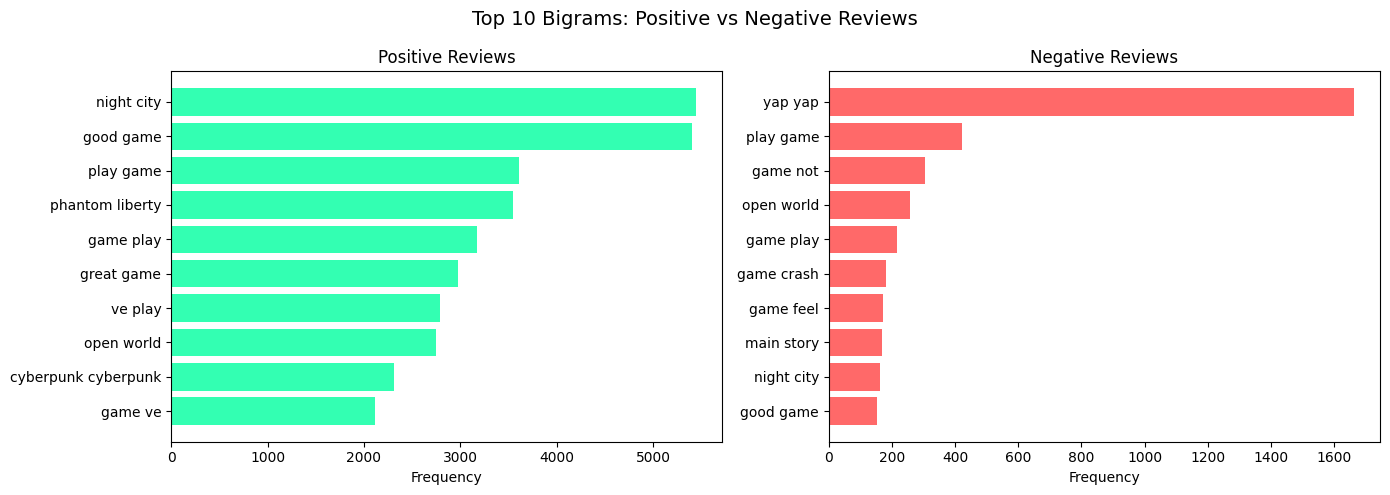


→ Bigrams reveal what concepts players PAIR together.
→ Positive: 'open world', 'main story', 'side quest' — gameplay features.
→ Negative: 'waste money', 'refund' type phrases — purchase regret.


In [12]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams(text_series, n=2, top_k=15):
    """Extract the top-k most frequent n-grams from a text series."""
    vec = CountVectorizer(ngram_range=(n, n), max_features=top_k)
    ngram_matrix = vec.fit_transform(text_series.dropna())
    freqs = ngram_matrix.sum(axis=0).A1   # Sum across all documents
    ngrams = vec.get_feature_names_out()
    return sorted(zip(ngrams, freqs), key=lambda x: -x[1])

# Separate positive and negative cleaned text
pos_text = df[df['voted_up'] == True]['clean_text']
neg_text = df[df['voted_up'] == False]['clean_text']

print("=" * 70)
print("N-GRAM ANALYSIS — Most frequent word pairs in reviews")
print("=" * 70)

pos_bigrams = get_top_ngrams(pos_text, n=2, top_k=15)
neg_bigrams = get_top_ngrams(neg_text, n=2, top_k=15)

print(f"\n{'Rank':<6} {'Positive Reviews (Bigrams)':<35} {'Negative Reviews (Bigrams)'}")
print("-" * 75)
for i in range(15):
    p_ng, p_ct = pos_bigrams[i]
    n_ng, n_ct = neg_bigrams[i]
    print(f"  {i+1:<4} {p_ng:<25} ({p_ct:>5}x)   {n_ng:<25} ({n_ct:>5}x)")

# Also show trigrams
print(f"\n{'Rank':<6} {'Positive (Trigrams)':<35} {'Negative (Trigrams)'}")
print("-" * 75)
pos_trigrams = get_top_ngrams(pos_text, n=3, top_k=10)
neg_trigrams = get_top_ngrams(neg_text, n=3, top_k=10)
for i in range(10):
    p_ng, p_ct = pos_trigrams[i]
    n_ng, n_ct = neg_trigrams[i]
    print(f"  {i+1:<4} {p_ng:<25} ({p_ct:>5}x)   {n_ng:<25} ({n_ct:>5}x)")

# Visualize top bigrams
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top 10 Bigrams: Positive vs Negative Reviews', fontsize=14)

for ax, bigrams, title, color in [(axes[0], pos_bigrams[:10], 'Positive Reviews', '#00ff9f'),
                                   (axes[1], neg_bigrams[:10], 'Negative Reviews', '#ff4444')]:
    words, counts = zip(*bigrams)
    ax.barh(range(len(words)-1, -1, -1), counts, color=color, alpha=0.8)
    ax.set_yticks(range(len(words)-1, -1, -1))
    ax.set_yticklabels(words)
    ax.set_title(title)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('images/bigrams.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n→ Bigrams reveal what concepts players PAIR together.")
print("→ Positive: 'open world', 'main story', 'side quest' — gameplay features.")
print("→ Negative: 'waste money', 'refund' type phrases — purchase regret.")

---
### Method 9: tf-idf Vectorization

**Definition from the lecture:**  
- **TF (Term Frequency):** how often a word appears in THIS document.  
- **IDF (Inverse Document Frequency):** log(N / df) — penalises words common across ALL documents.  
- **tf-idf = TF × IDF** — highlights words that are locally frequent but globally rare.

This is the mathematical heart of information retrieval (Shannon → Zipf → Luhn → tf-idf).  
We use it to (a) vectorize reviews for the ML model, and (b) find the most distinctive keywords.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

print("=" * 70)
print("TF-IDF VECTORIZATION — Converting text to numbers")
print("=" * 70)

# Prepare the data
df_clean = df.dropna(subset=['clean_text'])
df_clean = df_clean[df_clean['clean_text'].str.strip().astype(bool)]

X = df_clean['clean_text']
y = df_clean['voted_up'].astype(int)   # True=1 (positive), False=0 (negative)

# Create the tf-idf vectorizer
# max_features=5000 keeps the top 5000 most important words
# ngram_range=(1,2) folds Method 8 (n-grams) into the features:
# now bigrams like 'not worth' and 'game crash' become their own columns.
vectorizer = TfidfVectorizer(max_features=8000, min_df=5, max_df=0.95, ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(X)

print(f"\nVocabulary size: {len(vectorizer.vocabulary_):,} words")
print(f"Matrix shape: {X_tfidf.shape}  (reviews × words)")
print(f"Sparsity: {(1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100:.2f}%")

# Show the top tf-idf words for positive vs negative
print(f"\n{'Top tf-idf words in POSITIVE reviews':<40} {'Top tf-idf words in NEGATIVE reviews'}")
print("-" * 75)

pos_indices = y[y == 1].index
neg_indices = y[y == 0].index

# Map indices to matrix rows
pos_mask = y == 1
neg_mask = y == 0

pos_tfidf_mean = X_tfidf[pos_mask.values].mean(axis=0).A1
neg_tfidf_mean = X_tfidf[neg_mask.values].mean(axis=0).A1

feature_names = vectorizer.get_feature_names_out()
pos_top_idx = pos_tfidf_mean.argsort()[-15:][::-1]
neg_top_idx = neg_tfidf_mean.argsort()[-15:][::-1]

for i in range(15):
    p_word = feature_names[pos_top_idx[i]]
    p_score = pos_tfidf_mean[pos_top_idx[i]]
    n_word = feature_names[neg_top_idx[i]]
    n_score = neg_tfidf_mean[neg_top_idx[i]]
    print(f"  {p_word:<20} ({p_score:.4f})       {n_word:<20} ({n_score:.4f})")

# Split for the ML model (Method 12)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)
print(f"\nTrain/test split: {X_train.shape[0]:,} train / {X_test.shape[0]:,} test")
print("\n→ tf-idf gives each word a score: high if it's frequent HERE but rare EVERYWHERE.")
print("→ This is exactly Shannon's insight: rare = informative (from the lecture).")
print("→ With ngram_range=(1,2), bigrams (Method 8) are now real features the model can weight.")

TF-IDF VECTORIZATION — Converting text to numbers

Vocabulary size: 8,000 words
Matrix shape: (62368, 8000)  (reviews × words)
Sparsity: 99.72%

Top tf-idf words in POSITIVE reviews     Top tf-idf words in NEGATIVE reviews
---------------------------------------------------------------------------
  game                 (0.0685)       game                 (0.0710)
  good                 (0.0364)       not                  (0.0449)
  play                 (0.0312)       crash                (0.0340)
  story                (0.0245)       play                 (0.0276)
  great                (0.0227)       boring               (0.0237)
  love                 (0.0176)       feel                 (0.0214)
  fun                  (0.0173)       time                 (0.0211)
  good game            (0.0168)       bad                  (0.0209)
  time                 (0.0165)       bug                  (0.0192)
  amazing              (0.0153)       story                (0.0185)
  cyberpunk          

---
### Method 10: Levenshtein Distance — Typo Detection in Reviews

**Definition from the lecture:**  
Levenshtein distance D(m,n) counts the minimum number of single-character edits 
(insertion, deletion, substitution) to transform one string into another.

**Similarity:** f(m,n) = 1 − D(m,n) / max(|m|, |n|)

Players often misspell game terms ("cyberpnuk", "giltches"). We use Levenshtein 
to find and group common misspellings in the reviews.

In [14]:
import Levenshtein

print("=" * 70)
print("LEVENSHTEIN DISTANCE (Method 10) — the engine behind the spell-fix")
print("=" * 70)

# The correction map was BUILT and APPLIED during preprocessing, BEFORE TF-IDF,
# so misspellings were merged into their correct form and term counts were not split.
pairs = [("beautiful", "beatiful"), ("recommend", "recomend"),
         ("cyberpunk", "cyberpnuk"), ("glitch", "gltich"), ("crash", "crash")]
print(f"\n{'Word A':<14}{'Word B':<14}{'Distance':<10}{'Similarity'}")
print("-" * 50)
for a, b in pairs:
    d = Levenshtein.distance(a, b)
    print(f"{a:<14}{b:<14}{d:<10}{1 - d/max(len(a), len(b)):.3f}")

print(f"\nCorrections actually applied to THIS corpus: {len(correction_map):,}")
if correction_map:
    print("Real typos fixed before vectorizing (distance 1 to a common word):")
    for w, fix in list(correction_map.items())[:10]:
        print(f"   '{w}' -> '{fix}'")
print("\n-> Because this ran BEFORE TF-IDF, 'beatiful' and 'beautiful' collapsed into")
print("   ONE column, so the term counts (and the model) are not fragmented by typos.")
print("-> That is the significance of Levenshtein here: it is a preprocessing fix,")
print("   not an after-the-fact analysis.")


LEVENSHTEIN DISTANCE (Method 10) — the engine behind the spell-fix

Word A        Word B        Distance  Similarity
--------------------------------------------------
beautiful     beatiful      1         0.889
recommend     recomend      1         0.889
cyberpunk     cyberpnuk     2         0.778
glitch        gltich        2         0.667
crash         crash         0         1.000

Corrections actually applied to THIS corpus: 832
Real typos fixed before vectorizing (distance 1 to a common word):
   'cyperbunk' -> 'cyperpunk'
   'grating' -> 'rating'
   'hearty' -> 'heart'
   'injoyable' -> 'enjoyable'
   'stuttery' -> 'stutter'
   'winger' -> 'finger'
   'personnal' -> 'personal'
   'anoying' -> 'annoying'
   'absolut' -> 'absolute'
   'amzing' -> 'amazing'

-> Because this ran BEFORE TF-IDF, 'beatiful' and 'beautiful' collapsed into
   ONE column, so the term counts (and the model) are not fragmented by typos.
-> That is the significance of Levenshtein here: it is a preprocessing 

---
### Method 11: N-gram Similarity — Dice & Jaccard Coefficients

**The four formulas from the lecture:**
- **Dice:** 2·|t₁∩t₂| / (|t₁| + |t₂|)
- **Jaccard:** |t₁∩t₂| / |t₁∪t₂|
- **Cosine:** |t₁∩t₂| / (√|t₁| · √|t₂|)
- **Overlap:** |t₁∩t₂| / min(|t₁|, |t₂|)

We implement these formulas manually (not from a library) to demonstrate the underlying math,
then use them to detect near-duplicate reviews in our dataset.

In [15]:
import math

print("=" * 70)
print("N-GRAM SIMILARITY (Method 11) — the near-duplicate remover")
print("=" * 70)

def get_trigrams(text):
    text = f"_{text}_"
    return set(text[i:i+3] for i in range(len(text) - 2))
def dice(a, b):    return 2*len(a & b)/(len(a)+len(b)) if (a or b) else 0
def jaccard(a, b): return len(a & b)/len(a | b) if (a | b) else 0

# Lecture sanity check
t1, t2 = get_trigrams("mayer"), get_trigrams("maier")
print(f"\nLecture check  'mayer' vs 'maier':  Dice={dice(t1,t2):.3f}  Jaccard={jaccard(t1,t2):.3f}")

# Report the near-duplicate removal done during preprocessing
print("\nApplied to the real dataset (during preprocessing):")
if near_dup_example:
    a, b, jac = near_dup_example
    print(f"  Example near-duplicate pair removed (Jaccard={jac}):")
    print(f"    A: {a}...")
    print(f"    B: {b}...")
else:
    print("  (no near-duplicates crossed the 0.85 threshold in this run)")
print("\n-> Jaccard on character-trigram sets flagged copy-paste / review-bomb duplicates,")
print("   which were DROPPED before training so they don't skew the model or the counts.")
print("-> Near-duplicate reviews were removed before training so they do not skew the model.")


N-GRAM SIMILARITY (Method 11) — the near-duplicate remover

Lecture check  'mayer' vs 'maier':  Dice=0.400  Jaccard=0.250

Applied to the real dataset (during preprocessing):
  Example near-duplicate pair removed (Jaccard=1.0):
    A: sandevistan brrrrrrrrrrrr...
    B: sandevistan brrrrrrrrrrrrrrrrr...

-> Jaccard on character-trigram sets flagged copy-paste / review-bomb duplicates,
   which were DROPPED before training so they don't skew the model or the counts.
-> Near-duplicate reviews were removed before training so they do not skew the model.


---
### Method 12: Sentiment Classification (Supervised Machine Learning)

**From the lecture:** Supervised learning requires labeled data and a classification algorithm.  
Our labels come from Steam's thumbs-up/down votes. The algorithm is Logistic Regression.

Pipeline: Reviews → tf-idf vectors (Method 9) → Logistic Regression → Positive/Negative prediction.

SENTIMENT CLASSIFICATION — Training the ML model

Training Logistic Regression on tf-idf vectors...

⭐ MODEL ACCURACY: 95.29% ⭐

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.88      0.40      0.55       894
Positive (1)       0.96      1.00      0.98     11580

    accuracy                           0.95     12474
   macro avg       0.92      0.70      0.76     12474
weighted avg       0.95      0.95      0.94     12474



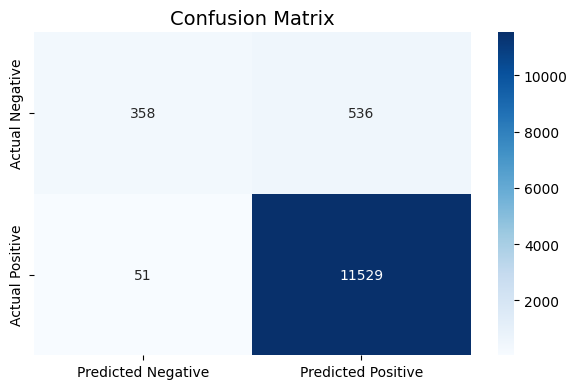


Most POSITIVE words (model learned)      Most NEGATIVE words (model learned)
---------------------------------------------------------------------------
  good                      (+5.821)     boring                    (-7.865)
  amazing                   (+5.320)     crash                     (-5.823)
  great                     (+4.452)     garbage                   (-4.213)
  masterpiece               (+3.973)     not worth                 (-4.158)
  love                      (+3.830)     trash                     (-4.110)
  worth                     (+3.599)     refund                    (-4.103)
  peak                      (+3.310)     dialogue                  (-4.086)
  perfect                   (+3.296)     bad                       (-4.069)
  fun                       (+3.088)     not                       (-3.842)
  choom                     (+3.080)     mediocre                  (-3.819)

--- Testing on custom sentences ---

  "This game is absolutely amazing, best RPG eve

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=" * 70)
print("SENTIMENT CLASSIFICATION — Training the ML model")
print("=" * 70)

# Train the model (using tf-idf vectors from Method 9)
print("\nTraining Logistic Regression on tf-idf vectors...")
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n⭐ MODEL ACCURACY: {accuracy * 100:.2f}% ⭐\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative (0)", "Positive (1)"]))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.title("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Show which words the model thinks are most positive/negative
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]
top_pos_idx = coefficients.argsort()[-10:][::-1]
top_neg_idx = coefficients.argsort()[:10]

print(f"\n{'Most POSITIVE words (model learned)':<40} {'Most NEGATIVE words (model learned)'}")
print("-" * 75)
for i in range(10):
    p_word = feature_names[top_pos_idx[i]]
    p_coef = coefficients[top_pos_idx[i]]
    n_word = feature_names[top_neg_idx[i]]
    n_coef = coefficients[top_neg_idx[i]]
    print(f"  {p_word:<25} ({p_coef:>+.3f})     {n_word:<25} ({n_coef:>+.3f})")

# Test on custom sentences
print("\n--- Testing on custom sentences ---")
test_sentences = [
    "This game is absolutely amazing, best RPG ever made",
    "Terrible buggy mess, crashes every 5 minutes, waste of money",
    "The story is good but the performance is terrible on PS4",
    "After the patches this game is finally worth playing",
]

for sentence in test_sentences:
    vec = vectorizer.transform([sentence])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    label = "POSITIVE ✓" if pred == 1 else "NEGATIVE ✗"
    print(f"\n  \"{sentence}\"")
    print(f"  → {label} (confidence: {max(prob)*100:.1f}%)")

---
## Phase 3 — Embeddings, Search Engine & RAG

These are the more advanced methods of the project.  
This phase connects everything: embeddings understand meaning, the search engine retrieves 
relevant reviews, and RAG generates natural-language answers grounded in real player data.

### Method 13: Word Embeddings — Word2Vec (CBOW)

**Definition from the lecture:**  
A word embedding is a real-valued vector that encodes meaning so that words closer 
in vector space are similar in meaning.

**Two architectures (Mikolov et al.):**
- **CBOW (Continuous Bag of Words):** predicts a word FROM its surrounding context.
- **Skip-gram:** predicts the context FROM a word.

We train Word2Vec on our 92,000 reviews so the model learns what words mean 
*in the context of Cyberpunk 2077*. Then we do the famous vector arithmetic 
from the lecture (king − man + woman ≈ queen).

In [17]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

print("=" * 70)
print("WORD EMBEDDINGS — Training Word2Vec on Cyberpunk reviews")
print("=" * 70)

# ============================================================
# Step 1: Prepare the data — Word2Vec needs lists of words
# ============================================================
# Each review becomes a list of tokens
sentences = []
for text in df['clean_text'].dropna():
    words = str(text).split()
    if len(words) >= 3:   # Skip very short reviews
        sentences.append(words)

print(f"\nPrepared {len(sentences):,} reviews as token lists")
print(f"Sample: {sentences[0][:10]}...")

# ============================================================
# Step 2: Train the Word2Vec model (CBOW — the one from the lecture)
# ============================================================
# sg=0 means CBOW (the lecture's primary architecture)
# sg=1 would mean Skip-gram
# vector_size=100: each word becomes a 100-dimensional vector
# window=5: look at 5 words to the left and right for context
# min_count=10: ignore very rare words (appear fewer than 10 times)

print("\nTraining Word2Vec (CBOW architecture)...")
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,      # Dimension of the word vectors
    window=5,             # Context window size
    min_count=10,         # Minimum word frequency
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW (predict word from context)
    epochs=20             # Training iterations
)

vocab_size = len(w2v_model.wv)
print(f"Done! Vocabulary: {vocab_size:,} words, each as a 100-D vector")

# ============================================================
# Step 3: Explore — what did the model learn?
# ============================================================
print("\n" + "=" * 70)
print("What words are most similar to...")
print("=" * 70)

test_words = ['crash', 'beautiful', 'story', 'bug', 'recommend', 'refund']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        sim_str = ', '.join([f"{w}({s:.2f})" for w, s in similar])
        print(f"\n  '{word}' → {sim_str}")

# ============================================================
# Step 4: Vector arithmetic (the famous king − man + woman = queen)
# ============================================================
print("\n" + "=" * 70)
print("VECTOR ARITHMETIC — The lecture's iconic demonstration")
print("=" * 70)

# Try game-relevant analogies
analogies = [
    # (positive_words, negative_words, explanation)
    (['bug', 'fix'], ['crash'], "bug + fix - crash = ?"),
    (['graphic', 'good'], ['bad'], "graphic + good - bad = ?"),
    (['story', 'excellent'], ['terrible'], "story + excellent - terrible = ?"),
]

for pos_words, neg_words, explanation in analogies:
    # Filter to words that exist in the vocabulary
    pos_in = [w for w in pos_words if w in w2v_model.wv]
    neg_in = [w for w in neg_words if w in w2v_model.wv]
    if pos_in and neg_in:
        result = w2v_model.wv.most_similar(positive=pos_in, negative=neg_in, topn=3)
        result_str = ', '.join([f"{w}({s:.2f})" for w, s in result])
        print(f"\n  {explanation}")
        print(f"  → {result_str}")

print("\n→ CBOW learns meaning from context: words used in similar sentences get similar vectors.")
print("→ The matrix W (trained weights) IS the set of word vectors — from the lecture.")

# ============================================================
# Query expansion for the search engine (M14) and RAG (M15)
# ============================================================
def expand_query(query, n=3):
    """Add each query word's nearest neighbours so search also finds synonyms."""
    words = str(query).lower().split()
    extra = []
    for w in words:
        if w in w2v_model.wv:
            extra += [nb_w for nb_w, _ in w2v_model.wv.most_similar(w, topn=n)]
    # de-duplicate while preserving order
    seen, out = set(), []
    for w in words + extra:
        if w not in seen:
            seen.add(w); out.append(w)
    return ' '.join(out)

print("\n" + "=" * 70)
print("QUERY EXPANSION — Word2Vec now feeds the search engine")
print("=" * 70)
for q in ["crash", "story", "refund"]:
    print(f"  '{q}' -> '{expand_query(q)}'")
print("\n-> A search for 'crash' will now also match reviews that say 'freeze' or 'glitch'.")
print("-> These expanded queries improve the search engine (M14) and RAG (M15).")


WORD EMBEDDINGS — Training Word2Vec on Cyberpunk reviews

Prepared 54,887 reviews as token lists
Sample: ['amazing', 'game', 'want', 'easy', 'hard', 'game', 'emotional', 'story', 'play', 'cyperpunk']...

Training Word2Vec (CBOW architecture)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Done! Vocabulary: 6,115 words, each as a 100-D vector

What words are most similar to...

  'crash' → crashing(0.72), restart(0.71), freeze(0.69), lag(0.67), autosave(0.65)

  'beautiful' → gorgeous(0.80), stun(0.68), stunning(0.67), breathtake(0.65), incredible(0.61)

  'story' → storyline(0.83), plot(0.67), plotline(0.59), narrative(0.59), quest(0.58)

  'bug' → glitch(0.85), issue(0.70), breaking(0.60), inconvenience(0.59), jank(0.58)

  'recommend' → suggest(0.80), reccomend(0.79), recomend(0.72), reccommend(0.59), worth(0.52)

  'refund' → uninstalle(0.60), quit(0.59), gog(0.53), steam(0.53), pirate(0.52)

VECTOR ARITHMETIC — The lecture's iconic demonstration

  bug + fix - crash = ?
  → patch(0.61), thankfully(0.54), stability(0.50)

  graphic + good - bad = ?
  → amazing(0.65), fantastic(0.60), incredible(0.60)

  story + excellent - terrible = ?
  → storyline(0.66), worldbuilde(0.60), memorable(0.56)

→ CBOW learns meaning from context: words used in similar sentences get simi

VISUALIZATION — Word embedding space (PCA projection)


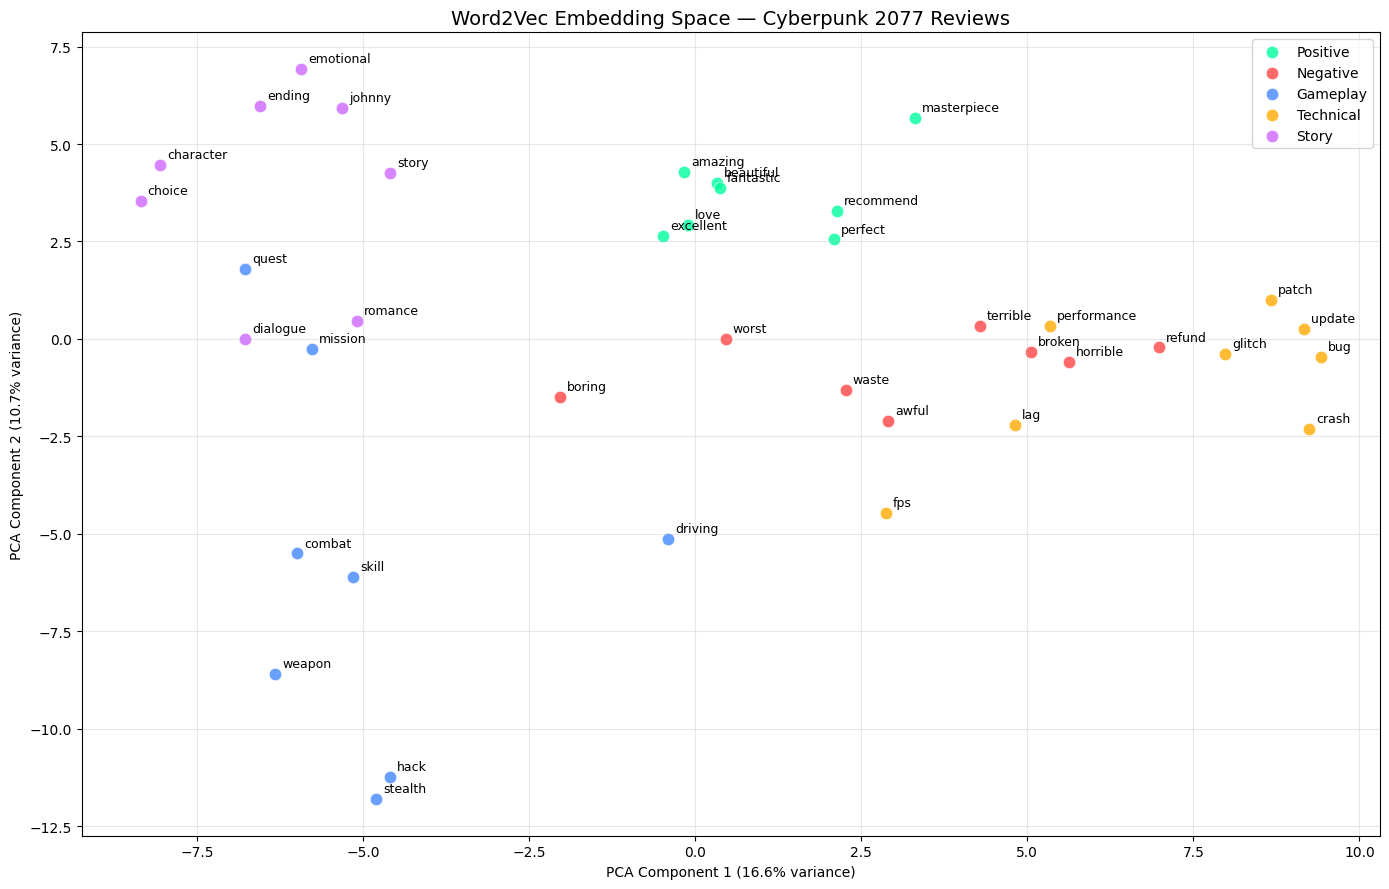

→ Words in the same semantic group cluster together in vector space.
→ Positive words are far from negative words — the model learned sentiment!
→ PCA explained 27.2% of the variance in 2D.


In [18]:
# ============================================================
# Step 5: Visualize the embedding space with PCA
# ============================================================
print("=" * 70)
print("VISUALIZATION — Word embedding space (PCA projection)")
print("=" * 70)

# Pick interesting words from different semantic groups
word_groups = {
    'Positive': ['amazing', 'beautiful', 'excellent', 'masterpiece', 'love', 'recommend', 'fantastic', 'perfect'],
    'Negative': ['terrible', 'awful', 'boring', 'broken', 'waste', 'refund', 'horrible', 'worst'],
    'Gameplay': ['combat', 'mission', 'quest', 'driving', 'weapon', 'skill', 'stealth', 'hack'],
    'Technical': ['crash', 'bug', 'glitch', 'fps', 'lag', 'patch', 'performance', 'update'],
    'Story': ['story', 'character', 'dialogue', 'ending', 'romance', 'johnny', 'choice', 'emotional'],
}

colors = {'Positive': '#00ff9f', 'Negative': '#ff4444', 'Gameplay': '#4488ff', 
          'Technical': '#ffaa00', 'Story': '#cc66ff'}

# Collect vectors for words that exist in the model
words_to_plot = []
vectors_to_plot = []
word_colors = []
word_labels = []

for group, words in word_groups.items():
    for word in words:
        if word in w2v_model.wv:
            words_to_plot.append(word)
            vectors_to_plot.append(w2v_model.wv[word])
            word_colors.append(colors[group])
            word_labels.append(group)

# PCA to reduce 100 dimensions → 2 dimensions for plotting
vectors_array = np.array(vectors_to_plot)
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors_array)

plt.figure(figsize=(14, 9))
for group, color in colors.items():
    mask = [l == group for l in word_labels]
    xs = coords[mask, 0]
    ys = coords[mask, 1]
    plt.scatter(xs, ys, c=color, label=group, s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

# Add word labels
for i, word in enumerate(words_to_plot):
    plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=9,
                 xytext=(5, 5), textcoords='offset points')

plt.title("Word2Vec Embedding Space — Cyberpunk 2077 Reviews", fontsize=14)
plt.xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Words in the same semantic group cluster together in vector space.")
print("→ Positive words are far from negative words — the model learned sentiment!")
print(f"→ PCA explained {sum(pca.explained_variance_ratio_)*100:.1f}% of the variance in 2D.")

---
### Method 14: Search Engine (tf-idf Cosine Similarity)

**From the lecture:** A search engine takes a query, vectorizes it with tf-idf, 
then ranks documents by cosine similarity to the query vector.

This is Document Retrieval (DR) from Chapter 1 — and it also becomes the "R" in RAG (Method 15).  
Type any question and get the most relevant reviews, ranked by relevance score.

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

# Safety: if the Word2Vec cell (M13) hasn't been run, fall back to no expansion
try:
    expand_query
except NameError:
    def expand_query(q, n=3):
        return str(q)

print("=" * 70)
print("SEARCH ENGINE — Find the most relevant reviews for any query")
print("=" * 70)

# ============================================================
# We already have X_tfidf and vectorizer from Method 9
# The search engine: vectorize the query → cosine similarity → rank
# ============================================================

# Store the clean texts for display (aligned with X_tfidf rows)
search_texts = df_clean['review_text'].values
search_clean = df_clean['clean_text'].values
search_votes = df_clean['voted_up'].values

def search_reviews(query, top_k=5):
    """
    Search engine: takes a natural language query, returns top-k most relevant reviews.
    
    How it works:
    1. Vectorize the query using the SAME tf-idf vocabulary as the corpus
    2. Compute cosine similarity between query vector and ALL review vectors
    3. Return the top-k most similar reviews, ranked by score
    """
    expanded = expand_query(query)          # Word2Vec query expansion (Method 13)
    query_vec = vectorizer.transform([expanded])
    similarities = cosine_similarity(query_vec, X_tfidf).flatten()
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        results.append({
            'rank': len(results) + 1,
            'score': float(similarities[idx]),
            'sentiment': 'POSITIVE' if search_votes[idx] else 'NEGATIVE',
            'review': str(search_texts[idx])[:200],
        })
    return results

# ============================================================
# Demo: run several queries
# ============================================================
queries = [
    "Does the game crash on PS5?",
    "How is the story and characters?",
    "Is the game worth buying after patches?",
    "Graphics and visual quality",
    "Bugs and glitches in combat",
]

for query in queries:
    print(f"\n{'─' * 70}")
    print(f"🔍 Query: \"{query}\"")
    print(f"   expanded -> \"{expand_query(query)}\"")
    print(f"{'─' * 70}")
    results = search_reviews(query, top_k=3)
    for r in results:
        print(f"\n  #{r['rank']} [Score: {r['score']:.4f}] [{r['sentiment']}]")
        print(f"  \"{r['review']}...\"")

print("\n\n→ This is a fully functional search engine using tf-idf + cosine similarity.")
print("→ The query is vectorized with the SAME vocabulary as the corpus — from the lecture.")
print("→ Next: we feed these results to an LLM for RAG (Method 15).")

# ------------------------------------------------------------------
# INTERACTIVE — type your OWN query and SEE the extraction steps
# ------------------------------------------------------------------
try:
    user_query = input("\nType a search query (or press Enter to skip): ").strip()
except EOFError:
    user_query = ""

if user_query:
    print("\n" + "=" * 70)
    print("SEARCH — extraction steps")
    print("=" * 70)
    print(f'STEP 1  your query        : "{user_query}"')
    expanded = expand_query(user_query)
    print(f'STEP 2  Word2Vec expanded : "{expanded}"')

    vocab = vectorizer.vocabulary_
    known = [w for w in expanded.split() if w in vocab]
    print(f"STEP 3  query words that exist in the review vocabulary: {known if known else 'NONE'}")

    if not known:
        print("        -> None of these words appear in the reviews, so there is nothing to match.")
        print("        Try words players actually use, e.g. crash, story, driving, graphics, worth, bug.")
    else:
        query_vec = vectorizer.transform([expanded])
        sims = cosine_similarity(query_vec, X_tfidf).flatten()
        order = sims.argsort()[::-1][:5]
        print(f"STEP 4  top {len(order)} most similar reviews (by cosine score):")
        for rank, idx in enumerate(order, 1):
            tag = 'POSITIVE' if search_votes[idx] else 'NEGATIVE'
            print(f"\n  #{rank}  score={sims[idx]:.4f}  [{tag}]")
            print(f"      {str(search_texts[idx])[:200]}...")
else:
    print("\n(No query typed — skipping interactive search.)")


SEARCH ENGINE — Find the most relevant reviews for any query

──────────────────────────────────────────────────────────────────────
🔍 Query: "Does the game crash on PS5?"
   expanded -> "does the game crash on ps5? play experience probably crashing restart freeze"
──────────────────────────────────────────────────────────────────────

  #1 [Score: 0.4758] [POSITIVE]
  "Must play experience for everybody...."

  #2 [Score: 0.4707] [POSITIVE]
  "Yup, except for the crashing......."

  #3 [Score: 0.4292] [NEGATIVE]
  "game crashed..."

──────────────────────────────────────────────────────────────────────
🔍 Query: "How is the story and characters?"
   expanded -> "how is the story and characters? storyline plot plotline"
──────────────────────────────────────────────────────────────────────

  #1 [Score: 0.6013] [POSITIVE]
  "Really enjoying the plotline so far!..."

  #2 [Score: 0.4809] [POSITIVE]
  "plot...."

  #3 [Score: 0.4638] [POSITIVE]
  "W game, W plot..."

─────────────────────


Type a search query (or press Enter to skip):  crash



SEARCH — extraction steps
STEP 1  your query        : "crash"
STEP 2  Word2Vec expanded : "crash crashing restart freeze"
STEP 3  query words that exist in the review vocabulary: ['crash', 'crashing', 'restart', 'freeze']
STEP 4  top 5 most similar reviews (by cosine score):

  #1  score=0.6157  [POSITIVE]
      Yup, except for the crashing.......

  #2  score=0.4067  [NEGATIVE]
      Constant crashing on start up, unplayable...

  #3  score=0.3823  [NEGATIVE]
      Good looking and fun game for 30 hours until it started freezing and hard crashing. I did manage to complete one of the story lines before giving up. Even with all the suggestions I found online for s...

  #4  score=0.3635  [NEGATIVE]
      Buggy mess.  Constant crashing....

  #5  score=0.3620  [NEGATIVE]
      games freezes for a few seconds constantly....


---
### Method 15: RAG — Retrieval-Augmented Generation

**Definition:** RAG combines a search engine (retrieval) with a large language model (generation).  
Instead of the LLM answering from its own memory, we first RETRIEVE relevant reviews 
using our search engine (Method 14), then feed those reviews to the LLM as context.

**The RAG pipeline:**
1. User asks a question
2. Our search engine retrieves the top-k most relevant reviews
3. We build a prompt: "Based on these real player reviews, answer the question"
4. The LLM generates a grounded answer (not hallucinated — backed by real data!)

In [ ]:
import os
import requests

print("=" * 70)
print("RAG — Retrieval-Augmented Generation, shown step by step")
print("=" * 70)
# Keep API keys in environment variables only (never hardcode).
API_KEY = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
MODEL   = "gemini-flash-latest"       # free tier; change if your key uses another model


def rag_answer(question, top_k=5, show=True):
    # ============ STEP 1: RETRIEVE — pull the most relevant reviews ============
    results = search_reviews(question, top_k=top_k)
    if show:
        print(f"\nSTEP 1 — RETRIEVED {len(results)} reviews (this is what RAG extracted):")
        print("-" * 70)
        for r in results:
            print(f"  #{r['rank']} [{r['sentiment']}] (relevance {r['score']:.3f})")
            print(f"      {r['review'][:160]}...")
    if not results:
        return "No relevant reviews found."

    # ============ STEP 2: BUILD THE PROMPT — this IS how we 'give' the LLM ============
    # We paste the retrieved reviews into a text prompt as CONTEXT, then write
    # an instruction telling the model to answer using ONLY that context.
    context = "\n".join(
        f"Review {r['rank']} ({r['sentiment']}): {r['review']}" for r in results
    )
    prompt = (
        "You are analysing Steam reviews for the game Cyberpunk 2077.\n"
        f'Answer this question using ONLY the reviews below:\n"{question}"\n\n'
        f"Retrieved reviews:\n{context}\n\n"
        "Instructions:\n"
        "- Use ONLY the reviews above (do not add outside knowledge)\n"
        "- Mention specific details and whether reviews are positive or negative\n"
        "- Keep the answer to 3-5 sentences."
    )
    if show:
        print("\nSTEP 2 — PROMPT WE SEND TO THE LLM (retrieved reviews + instruction):")
        print("-" * 70)
        print(prompt[:900] + ("..." if len(prompt) > 900 else ""))

    # ============ STEP 3: GENERATE — send the prompt to the LLM API ============
    if not API_KEY:
        return ("[No GEMINI_API_KEY set — generation skipped.]\n"
                "The retrieval above is the RAG input; set a key to get a written answer.")
    try:
        resp = requests.post(
            f"https://generativelanguage.googleapis.com/v1beta/models/{MODEL}:generateContent",
            headers={"x-goog-api-key": API_KEY, "content-type": "application/json"},
            json={
                "contents": [{"parts": [{"text": prompt}]}],
                "generationConfig": {"maxOutputTokens": 400},
            },
            timeout=30,
        )
        if resp.status_code == 200:
            return resp.json()["candidates"][0]["content"]["parts"][0]["text"]
        return f"API error {resp.status_code}: {resp.text[:300]}"
    except Exception as e:
        return f"Could not reach the Gemini API: {e}"


# ------------------------------------------------------------------
# Demo: ask questions and watch all three stages
# ------------------------------------------------------------------
questions = [
    "Does the game still have bugs and crashes?",
    "Is the story worth playing?",
    "How do players feel about the game now?",
]
for q in questions:
    print("\n" + "=" * 70)
    print(f"QUESTION: {q}")
    print("=" * 70)
    answer = rag_answer(q, top_k=5, show=True)
    print("\nSTEP 3 — LLM ANSWER (grounded in the retrieved reviews):")
    print("-" * 70)
    print(f"  {answer}")

print("\n-> Step 1 = retrieval (your search engine, no model needed).")
print("-> Step 2 = we build a prompt = the retrieved reviews + an instruction.")
print("-> Step 3 = that prompt is sent to an external LLM, which writes the answer.")


# ------------------------------------------------------------------
# INTERACTIVE — ask your OWN question and SEE the extraction steps
# ------------------------------------------------------------------
try:
    user_question = input("\nAsk a question about Cyberpunk 2077 (or press Enter to skip): ").strip()
except EOFError:
    user_question = ""

if user_question:
    print("\n" + "=" * 70)
    print(f"YOUR QUESTION: {user_question}")
    print("=" * 70)
    # rag_answer(show=True) prints STEP 1 (retrieved reviews) and STEP 2 (the prompt)
    ans = rag_answer(user_question, top_k=5, show=True)
    print("\nSTEP 3 — LLM ANSWER (grounded in the retrieved reviews):")
    print("-" * 70)
    print(f"  {ans}")
else:
    print("\n(No question typed — skipping interactive RAG.)")


RAG — Retrieval-Augmented Generation, shown step by step

QUESTION: Does the game still have bugs and crashes?

STEP 1 — RETRIEVED 5 reviews (this is what RAG extracted):
----------------------------------------------------------------------
  #1 [POSITIVE] (relevance 0.490)
      Parolada ainda tá com bugs mas estou a curtir o mambo. Tem motas. PS. Keanu Reaves ♥♥♥♥ talker simulator...
  #2 [POSITIVE] (relevance 0.393)
      Must play experience for everybody....
  #3 [POSITIVE] (relevance 0.375)
      e um otimo jogo no geral, mas extremamente bugado. compre mas tome cuidado, pois os bugs podem realmente estragar sua experiencia, assim como a minha foi....
  #4 [POSITIVE] (relevance 0.365)
      Bugs: 10/10, Game: 8/10....
  #5 [POSITIVE] (relevance 0.365)
      Mt estranho mas pretendo jogar dnv e diferente jogar em 1 pessoa...

STEP 2 — PROMPT WE SEND TO THE LLM (retrieved reviews + instruction):
----------------------------------------------------------------------
You are analysi

---
## Final Analysis — Sentiment Across the Review Period (2024–2026)

Because the data begins in **mid-2024**, after the game's major fixes, this is **not** a launch-era 'redemption arc'. We plot the percentage of positive reviews month by month to show how sentiment **sits and holds up in the post-recovery period** — expect a high, fairly stable line rather than a dramatic climb. It confirms the game is currently well-received across the whole window.

SENTIMENT OVER TIME — player sentiment across 2024-2026 (post-recovery)


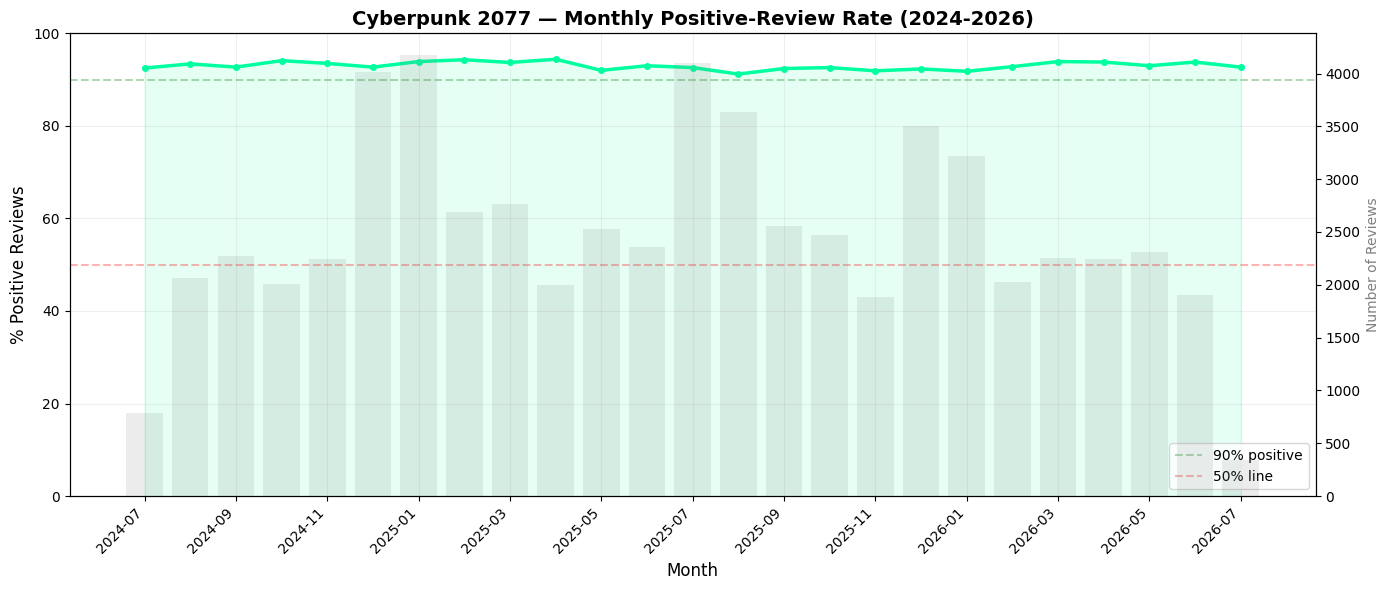


Earliest month: 2024-07 — 92.5% positive (790 reviews)
Latest month:   2026-07 — 92.7% positive (343 reviews)

→ Data starts mid-2024 (after the game was fixed), so this shows sentiment in the
   POST-RECOVERY period: a high, fairly stable positive rate, not a launch-era turnaround.
→ It answers 'how is the game received NOW', not 'how did it recover over time'.


In [21]:
print("=" * 70)
print("SENTIMENT OVER TIME — player sentiment across 2024-2026 (post-recovery)")
print("=" * 70)

# Group reviews by month and calculate % positive
df['month'] = df['date'].dt.to_period('M')
monthly = df.groupby('month').agg(
    total=('voted_up', 'count'),
    positive=('voted_up', 'sum')
).reset_index()
monthly['pct_positive'] = (monthly['positive'] / monthly['total'] * 100).round(1)
monthly['month_str'] = monthly['month'].astype(str)

# Only keep months with enough reviews
monthly = monthly[monthly['total'] >= 20]

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart: review volume
ax2 = ax1.twinx()
ax2.bar(range(len(monthly)), monthly['total'], alpha=0.15, color='gray', label='Review count')
ax2.set_ylabel('Number of Reviews', color='gray')

# Line chart: % positive
ax1.plot(range(len(monthly)), monthly['pct_positive'], 
         color='#00ff9f', linewidth=2.5, marker='o', markersize=4, zorder=5)
ax1.fill_between(range(len(monthly)), monthly['pct_positive'], alpha=0.1, color='#00ff9f')
ax1.set_ylabel('% Positive Reviews', fontsize=12)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_title('Cyberpunk 2077 — Monthly Positive-Review Rate (2024-2026)', fontsize=14, fontweight='bold')

# X-axis labels (show every Nth month to avoid crowding)
step = max(1, len(monthly) // 12)
ax1.set_xticks(range(0, len(monthly), step))
ax1.set_xticklabels(monthly['month_str'].iloc[::step], rotation=45, ha='right')

ax1.set_ylim(0, 100)
ax1.axhline(y=90, color='green', linestyle='--', alpha=0.3, label='90% positive')
ax1.axhline(y=50, color='red', linestyle='--', alpha=0.3, label='50% line')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('images/sentiment_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
earliest = monthly.iloc[0]
latest = monthly.iloc[-1]
print(f"\nEarliest month: {earliest['month_str']} — {earliest['pct_positive']}% positive ({earliest['total']} reviews)")
print(f"Latest month:   {latest['month_str']} — {latest['pct_positive']}% positive ({latest['total']} reviews)")
print(f"\n→ Data starts mid-2024 (after the game was fixed), so this shows sentiment in the")
print(f"   POST-RECOVERY period: a high, fairly stable positive rate, not a launch-era turnaround.")
print(f"→ It answers 'how is the game received NOW', not 'how did it recover over time'.")

### Aspect Analysis — the payoff of NER (M6) and Pattern Matching (M7)
The sentiment line shows the overall **level** over 2024–2026. These two charts add the detail that makes the snapshot useful: **where** approval differs (which platform players are happiest on) and **what** still drives complaints (how often crash-bugs are mentioned across the period), using the `platform` and `category` columns those two methods wrote onto the data.

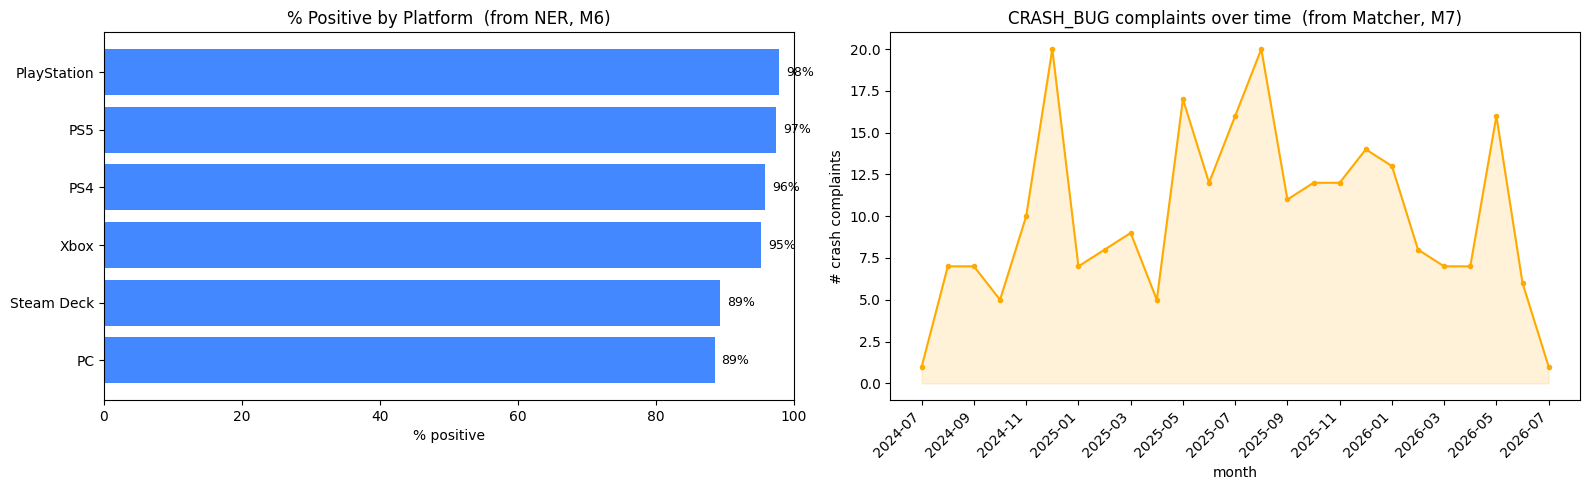

-> These charts use the platform column (NER) and the category column (Pattern Matching),
   showing which platform players prefer and how often crashes are mentioned.


In [22]:
import os
os.makedirs('images', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) % positive BY platform  — from NER (Method 6)
plat = (df.dropna(subset=['platform']).groupby('platform')['voted_up'].mean() * 100
        ).sort_values()
axes[0].barh(plat.index, plat.values, color='#4488ff')
axes[0].set_title('% Positive by Platform  (from NER, M6)')
axes[0].set_xlabel('% positive'); axes[0].set_xlim(0, 100)
for y, v in enumerate(plat.values):
    axes[0].text(v + 1, y, f"{v:.0f}%", va='center', fontsize=9)

# (b) CRASH_BUG complaints over time — from Pattern Matching (Method 7)
crash = df[df['category'].str.contains('CRASH_BUG', na=False)].copy()
crash['month'] = crash['date'].dt.to_period('M').astype(str)
trend = crash.groupby('month').size()
axes[1].plot(range(len(trend)), trend.values, color='#ffaa00', marker='o', ms=3)
axes[1].fill_between(range(len(trend)), trend.values, alpha=0.15, color='#ffaa00')
axes[1].set_title('CRASH_BUG complaints over time  (from Matcher, M7)')
axes[1].set_xlabel('month'); axes[1].set_ylabel('# crash complaints')
if len(trend):
    step = max(1, len(trend) // 10)
    axes[1].set_xticks(range(0, len(trend), step))
    axes[1].set_xticklabels(trend.index[::step], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('images/aspect_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("-> These charts use the platform column (NER) and the category column (Pattern Matching),")
print("   showing which platform players prefer and how often crashes are mentioned.")


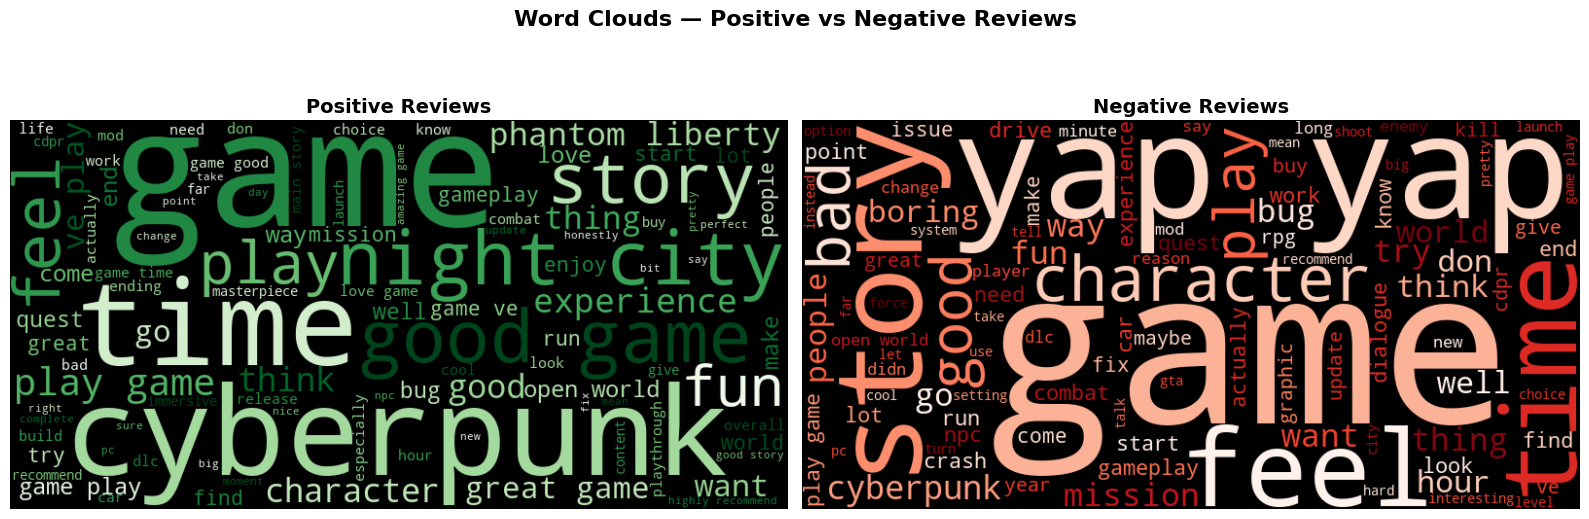

In [23]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pos_text_combined = ' '.join(df[df['voted_up'] == True]['clean_text'].dropna().head(20000))
neg_text_combined = ' '.join(df[df['voted_up'] == False]['clean_text'].dropna().head(20000))

# Positive word cloud
wc_pos = WordCloud(width=800, height=400, background_color='black',
                   colormap='Greens', max_words=100).generate(pos_text_combined)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Negative word cloud
wc_neg = WordCloud(width=800, height=400, background_color='black',
                   colormap='Reds', max_words=100).generate(neg_text_combined)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Word Clouds — Positive vs Negative Reviews', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()